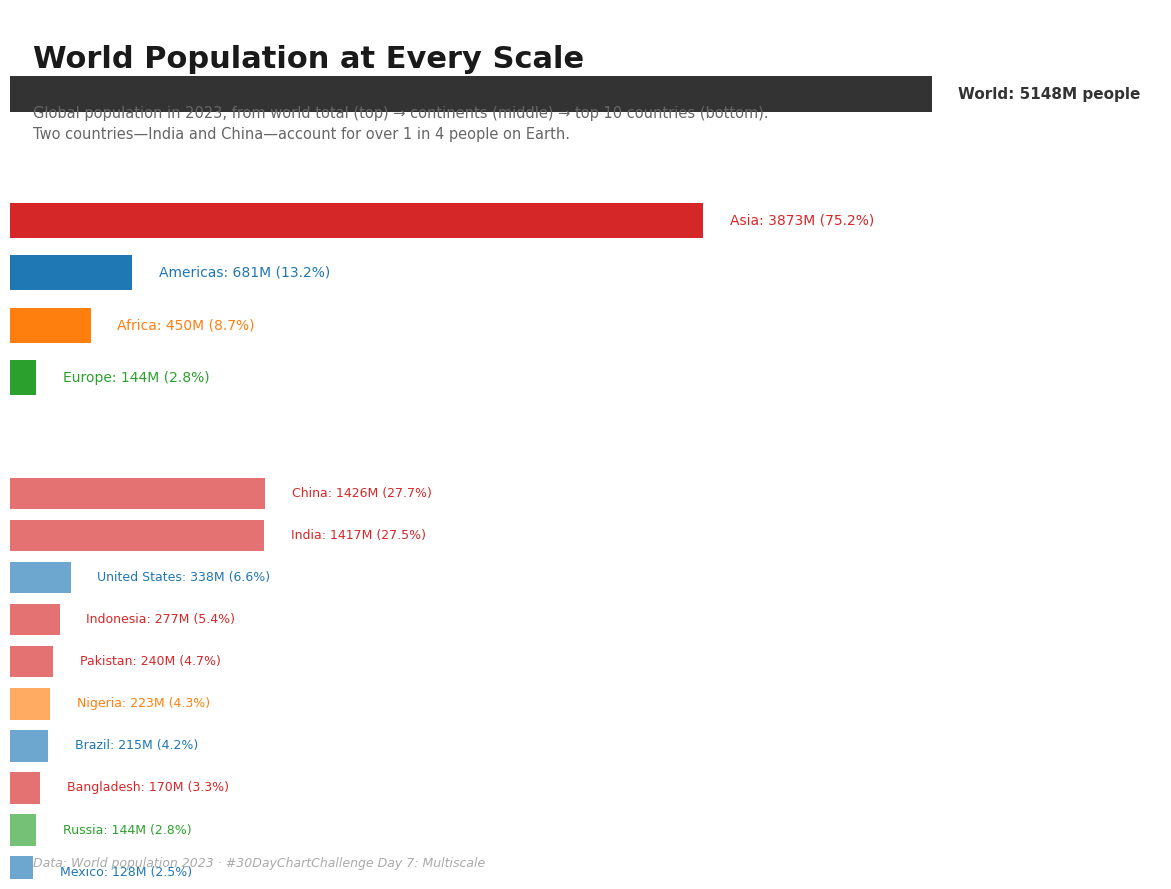

In [3]:
"""
#30DayChartChallenge — Day 7: Multiscale
"World Population at Every Scale" — hierarchical breakdown
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: World population by country and continent (2023)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — World population 2023 (Millions)
# ---------------------------------------------------------------------------
data = {
    "Entity": [
        "India", "China", "United States", "Indonesia", "Pakistan",
        "Brazil", "Nigeria", "Bangladesh", "Russia", "Mexico",
        "Japan", "Ethiopia", "Philippines", "Egypt", "Vietnam"
    ],
    "Continent": [
        "Asia", "Asia", "Americas", "Asia", "Asia",
        "Americas", "Africa", "Asia", "Europe", "Americas",
        "Asia", "Africa", "Asia", "Africa", "Asia"
    ],
    "population": [
        1417, 1426, 338, 277, 240,
        215, 223, 170, 144, 128,
        125, 123, 120, 104, 98
    ]
}

df = pd.DataFrame(data)

# Aggregate by continent
continental = df.groupby("Continent")["population"].sum().sort_values(ascending=False)
global_total = df["population"].sum()

# Top 10 countries
top_countries = df.sort_values("population", ascending=False).head(10)

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 9), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

palette_continent = {
    "Asia": "#d62728",
    "Africa": "#ff7f0e",
    "Europe": "#2ca02c",
    "Americas": "#1f77b4",
    "Oceania": "#9467bd",
}

# Y-axis layout: global → continents → top countries
y_pos = 0

# Global bar
ax.barh([y_pos], [global_total], height=0.5, color="#333333", edgecolor="none", zorder=3)
ax.text(global_total + 150, y_pos, f"World: {global_total:.0f}M people", 
        fontsize=11, fontweight="bold", color="#333333", va="center")
y_pos -= 1.8

# Continental bars
for continent, val in continental.items():
    color = palette_continent.get(continent, "#999999")
    ax.barh([y_pos], [val], height=0.5, color=color, edgecolor="none", zorder=3)
    pct = (val / global_total) * 100
    ax.text(val + 150, y_pos, f"{continent}: {val:.0f}M ({pct:.1f}%)", 
            fontsize=10, fontweight="500", color=color, va="center")
    y_pos -= 0.75

y_pos -= 0.9

# Country bars
for idx, row in top_countries.iterrows():
    color = palette_continent.get(row["Continent"], "#999999")
    ax.barh([y_pos], [row["population"]], height=0.45, color=color, alpha=0.65, edgecolor="none", zorder=3)
    pct = (row["population"] / global_total) * 100
    ax.text(row["population"] + 150, y_pos, f"{row['Entity']}: {row['population']:.0f}M ({pct:.1f}%)", 
            fontsize=9, color=color, va="center")
    y_pos -= 0.6

# Minimal styling
ax.set_xlim(0, global_total * 1.25)
ax.set_ylim(y_pos + 0.5, 1.2)
ax.axis("off")

# Title & subtitle
ax.text(0.02, 0.96, "World Population at Every Scale",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.89,
        "Global population in 2023, from world total (top) → continents (middle) → top 10 countries (bottom).\n"
        "Two countries—India and China—account for over 1 in 4 people on Earth.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Source
ax.text(0.02, 0.01,
        "Data: World population 2023 · #30DayChartChallenge Day 7: Multiscale",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day7_multiscale.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()